# Linear response TD-OFDFT Tutorials

This tutorial shows how to run Casida TD-OFDFT calculations with DFTpy. It uses the same setup as the companion **[Real time TD-OFDFT tutorial](td-ofdft-tutorial.ipynb)** (save the RT traces / `td_ofdft_rt_reference.h5` there if you want to compare spectra here). You will learn:

- How to run Casida TD-OFDFT calculations

Run this cell to install DFTpy in google colab

```bash
!python -m pip install "git+https://github.com/Quantum-MultiScale/DFTpy.git@dev"
```

Download the pseudopotential file

```bash
!wget https://raw.githubusercontent.com/Quantum-MultiScale/DFTpy/dev/DATA/Mg8.vasp
!wget https://raw.githubusercontent.com/Quantum-MultiScale/DFTpy/dev/DATA/Mg_OEPP_PZ.UPF

```


First we need to load the necesary modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 15,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 14,
        "axes.unicode_minus": False,
    }
)

from dftpy.grid import DirectGrid
from dftpy.field import DirectField
from dftpy.functional import Functional, TotalFunctional
from dftpy.optimization import Optimization
from dftpy.constants import LEN_CONV, ENERGY_CONV
from dftpy.formats.vasp import read_POSCAR
from dftpy.td.hamiltonian import Hamiltonian

# Load the Casida modules
from dftpy.td.casida import Casida
from dftpy.td.interface import CasidaRunner
from dftpy.td.hamiltonian import Hamiltonian

Set up the systems and the initial density

In [2]:


DATA='../DATA/'
structure_file = DATA+'Mg8.vasp'
atoms = read_POSCAR(structure_file, names=['Mg'])
PP_list = {'Mg':DATA+'Mg_OEPP_PZ.UPF'}
nr = [36, 36, 32]
grid = DirectGrid(atoms.cell, nr)
nelec = 16
rho_ini = np.ones(nr)
rho_ini = DirectField(grid=grid, griddata_3d=rho_ini)
rho_ini = rho_ini / rho_ini.integral() * nelec



Build the total energy density functional and get the ground state density

In [3]:
ke = Functional(type='KEDF',name='TFvW')
xc = Functional(type='XC',name='LDA', libxc=False)
hartree = Functional(type='HARTREE')
pseudo = Functional(type='PSEUDO', grid=grid, ions=atoms, PP_list=PP_list)
totalfunctional = TotalFunctional(KineticEnergyFunctional=ke,
                                XCFunctional=xc, 
                                HARTREE=hartree, 
                                PSEUDO=pseudo
                                 )

optimization_options = {'econv' : 1e-10 * nelec,
                        'maxfun' : 50,
                        'maxiter' : 100}

opt = Optimization(EnergyEvaluator=totalfunctional, optimization_options = optimization_options,
        optimization_method = 'TN')
rho0 = opt.optimize_rho(guess_rho=rho_ini)

setting key: Mg -> ../DATA/Mg_OEPP_PZ.UPF
Step    Energy(a.u.)            dE              dP              Nd      Nls     Time(s)         
0       8.951916882520E+00      8.951917E+00    2.343046E+00    1       1       2.524233E-02    
!WARN: Change to steepest decent
1       -4.970850195117E+00     -1.392277E+01   1.121758E+00    1       3       5.266213E-02    
2       -5.991894332924E+00     -1.021044E+00   1.516348E-01    4       2       7.940507E-02    
3       -6.128065576848E+00     -1.361712E-01   1.802917E-02    8       3       1.207283E-01    
4       -6.143827137693E+00     -1.576156E-02   3.111792E-03    10      3       1.696901E-01    
5       -6.146022421154E+00     -2.195283E-03   3.902247E-04    7       3       2.043753E-01    
6       -6.146449721223E+00     -4.273001E-04   4.586828E-05    10      3       2.555830E-01    
7       -6.146493566939E+00     -4.384572E-05   6.805825E-06    7       3       2.923172E-01    
8       -6.146501643512E+00     -8.076573E-06   7.72

In [4]:
ke.options.update({'y':0}) # Remove the von Weizsacker term since the laplacian is included in the Hamiltonian

totalfunctional = TotalFunctional(KEDF=ke, XC=xc, HARTREE=hartree, PSEUDO=pseudo)

In [5]:
v2 = totalfunctional(rho0, calcType='V2').v2rho2

To build the casida matrix we get the orbitals from the hamiltonian of the orbital free DFT system
$$
\underbrace{\left[-\frac{1}{2} \nabla^2 + v_B(n_0) \right]}_{\hat{H}_B}\phi(\vec{r})= \mu \phi(\vec{r})
$$

The diagonalization of the hamiltonian will lead to a set of eigenfunctions $\{\phi(\vec{r})\}$ where the eigenfunction with lowest energy is the ground state density and yields the ground state density $n_0(\vec{r}) = |\phi_0(\vec{r})|$

In [6]:
numeig = 150
potential = totalfunctional(rho0, calcType={'V'}).potential

hamiltonian = Hamiltonian(potential)
eigs, psi_list = hamiltonian.diagonalize(numeig)

totalfunctional.UpdateFunctional(keysToRemove=['HARTREE', 'PSEUDO'])

Once we get the eigenfunctions we can build the Casida matrix in the following way 
$$
\sum_j \left[ \delta_{ij} \omega_{ij}^2 + 2 \sqrt{\omega_{ij}} K_{ij,i'j'} \sqrt{\omega_{j'k'}} \right] F_{j'k'} = \Omega^2 F_{ik}
$$
Where $K_{ij,i'j'}$ is refer as the soupling matrix and has the following form
$$
K_{ij,j'k'}(\Omega) = \int d^3r \int d^3r' \phi_{ji}(\mathbf{r}) f_{{PHxc}}(\mathbf{r},\mathbf{r}',\Omega) \phi_{j'i'}^*(\mathbf{r}')
$$

In [7]:
casida = Casida(rho0, totalfunctional)
casida.build_matrix(numeig, eigs, psi_list, build_ab=True)
omega, f, x_minus_y_list = casida()


Postprocess the oscillator strengths to plo the optical spectra

In [8]:
def gauss(freq,omega,sigma):
    return np.exp(- (freq - omega * 27.2114) ** 2 / 2.0 / sigma)/np.sqrt(2.0*np.pi)/sigma

def smooth(f, omega, sigma):
    s=np.zeros_like(freq)
    for i in range(0,len(omega)):
        s += gauss(freq,omega[i],sigma) * f[i] 
    return s

def get_spectra_lr(f, omega, sigma):
    slr = smooth(f, omega, sigma)
    return slr

In [9]:
freq = np.linspace(0, 200, 78540)
sof_lr = get_spectra_lr(f, omega, sigma=0.01)

Read the data from the Real time propagation and compare with the Linear response results

In [10]:
import h5py
import numpy as np
from pathlib import Path

from dftpy.td.utils import calc_spectra_mu
from dftpy.constants import Units
with h5py.File(Path("td_ofdft_rt_reference.h5"), "r") as f:
    t_rt = f["runner2/t"][:]
    dmu_rt = f["runner2/dipole"][:, 0]
    interval = float(f["meta/interval"][()])
    kick = float(f["meta/k"][()])

omega_rt, spectra_rt = calc_spectra_mu(dmu_rt, interval, kick=kick, sigma=1e-5)

Plot the optical spectra from both methods

Text(0, 0.5, 'Intensity (a.u.)')

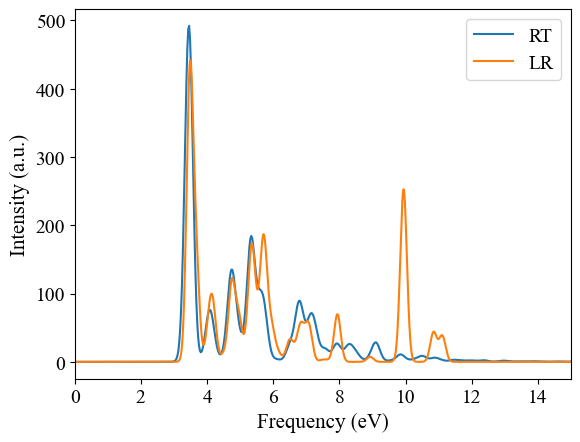

In [50]:
plt.plot(omega_rt * Units.Ha, spectra_rt, label='RT')
plt.plot(freq, sof_lr*3, label='LR')
plt.xlim(0,15)
plt.legend()
plt.xlabel('Frequency (eV)')
plt.ylabel('Intensity (a.u.)')